# MLP Regressor para previsão do preço semanal do ouro

## Base de dados

Base: `gold.daily.prices.csv`

Série de preços do ouro agregada para semanas encerradas na sexta-feira. O alvo é o último valor válido `VALUE` de cada semana.

- **Granularidade:** semanal (`W-FRI`)
- **Random state:** 42
- **Divisão temporal:** 75% inicial para treino e 25% final para teste

## Importações e configurações


In [1]:
from copy import deepcopy
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import sys

PROJECT_ROOT = next(
    (pasta for pasta in (Path.cwd(), *Path.cwd().parents)
     if (pasta / 'validacao_bases.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Não foi possível localizar validacao_bases.py a partir do diretório atual.'
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from funcoes_series_temporais import (
    analisar_componente_residual, calcular_forca_sazonalidade,
    calcular_importancia_features,
)

In [2]:
BASE_NAME = 'ouro'
SEED = 42
HORIZON = 1
SEASONAL_PERIOD = 52
SEASONAL_NAME = 'anual'
PERIOD_LABEL = 'semana'
PERIOD_LABEL_PLURAL = 'semanas'
TARGET_UNIT = 'unidade monetária'
VISUAL_RESAMPLE = '13W-FRI'
VISUAL_LABEL = 'médias de 13 semanas'
MIN_VALIDATION_SAMPLES = 52
LJUNG_LAGS = [1, 4, 13, 26, 52]
MAX_ACF_LAG = 52
print(f"Base: {BASE_NAME}")

Base: ouro


## Configuração do MLP Regressor


In [3]:
# Configuração causal compartilhada para a base selecionada.
from features_temporais import configuracao_features

FEATURE_CONFIG = configuracao_features(BASE_NAME)
TARGET_LAGS = sorted(set(FEATURE_CONFIG.lags_alvo) | {SEASONAL_PERIOD})
EXOG_LAGS = {coluna: list(lags) for coluna, lags in FEATURE_CONFIG.lags_exogenas.items()}
EXOG_COLUMNS = list(EXOG_LAGS)
ROLLING_WINDOWS = list(FEATURE_CONFIG.janelas_moveis)
CALENDAR_COMPONENTS = list(FEATURE_CONFIG.calendario)
KNOWN_INDICATORS = dict(FEATURE_CONFIG.indicadores_conhecidos)
SCALER = 'standard'
VALIDATION_RATIO = 0.15
PATIENCE = 20
MIN_DELTA = 1e-4
BATCH_SIZE = 128
N_SPLITS_VALIDACAO = 3
MESES_VALIDACAO = 6
MAX_AMOSTRA_MAE_TREINO = 5000
CANDIDATOS_MLP = [
    {'nome': 'simples_32_relu_adam', 'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-4, 'max_iter': 100},
    {'nome': 'media_64_relu_adam', 'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-3, 'max_iter': 120},
    {'nome': 'aula_64x64_relu_adam', 'hidden_layer_sizes': (64, 64), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-4, 'max_iter': 100},
    {'nome': 'simples_32_tanh_adam', 'hidden_layer_sizes': (32,), 'activation': 'tanh', 'solver': 'adam', 'alpha': 1e-3, 'max_iter': 100},
    {'nome': 'simples_32_relu_sgd', 'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'sgd', 'alpha': 1e-4, 'max_iter': 120},
]

# 1. Preparação da base


## Base tratada

- **Objetivo:** carregar a série regularizada e preservar o corte cronológico entre treino e teste.
- **Importância:** todos os modelos da base partem da mesma amostra, permitindo uma comparação justa.
- **Cuidado:** os lags são calculados antes da remoção das linhas incompletas para manter o alinhamento temporal.

In [4]:
# Carrega a base tratada e verifica sua integridade.
from preparacao_bases import carregar_base_tratada

df, metadados_base = carregar_base_tratada(BASE_NAME, PROJECT_ROOT)
TARGET_COLUMN = metadados_base['alvo']
FREQUENCY = metadados_base['frequencia']
TRAIN_RATIO = metadados_base['treino']
SEED = metadados_base['seed']
FIM_TREINO = pd.Timestamp(metadados_base['fim_treino'])
INICIO_TESTE = pd.Timestamp(metadados_base['inicio_teste'])
np.random.seed(SEED)
diagnostico_base = pd.DataFrame([{
    'base': BASE_NAME, 'linhas': len(df), 'alvos_ausentes': int(df[TARGET_COLUMN].isna().sum()),
    'fim_treino': FIM_TREINO, 'inicio_teste': INICIO_TESTE, 'seed': SEED,
}])
display(diagnostico_base)

,base,linhas,alvos_ausentes,fim_treino,inicio_teste,seed
0,ouro,2402,0,2002-10-04,2002-10-11,42


## Dicionário de dados

- **Alvo:** preço semanal `VALUE`.
- **Entradas:** lags do próprio alvo, estatísticas móveis e calendário cíclico.
- **Exógenas:** a base não possui variáveis exógenas disponíveis para a modelagem.
- **Importância:** o valor da semana prevista nunca pode entrar como feature.

In [5]:
# Registra o papel e a disponibilidade temporal das variáveis.
colunas_dicionario = [TARGET_COLUMN, *EXOG_COLUMNS, *KNOWN_INDICATORS]
dicionario = pd.DataFrame([
    {
        'variavel': coluna,
        'papel': (
            'alvo' if coluna == TARGET_COLUMN
            else 'indicador conhecido' if coluna in KNOWN_INDICATORS
            else 'exogena defasada'
        ),
        'tipo': str(df[coluna].dtype),
        'uso_no_modelo': (
            'valor do período conhecido antecipadamente'
            if coluna in KNOWN_INDICATORS else 'somente valores de períodos anteriores'
        ),
    }
    for coluna in colunas_dicionario
]).set_index('variavel')
display(dicionario)

,papel,tipo,uso_no_modelo
variavel,,,
VALUE,alvo,float64,somente valores de períodos anteriores


## Análise exploratória

A exploração verifica:

- distribuição e evolução temporal das variáveis;
- valores ausentes e possíveis outliers pelo intervalo interquartil;
- padrões que podem orientar lags e janelas móveis.

> Os outliers são sinalizados, mas não removidos automaticamente, pois valores extremos podem ser observações reais.

,n,ausentes,media,desvio_padrao,minimo,q1,mediana,q3,maximo,limite_iqr_inferior,limite_iqr_superior,sinais_outlier_iqr,percentual_outlier_iqr
variavel,,,,,,,,,,,,,
VALUE,2402,0,446.568,382.241,34.775,260.812,364.55,445.838,1879.5,-16.725,723.375,344,0.143


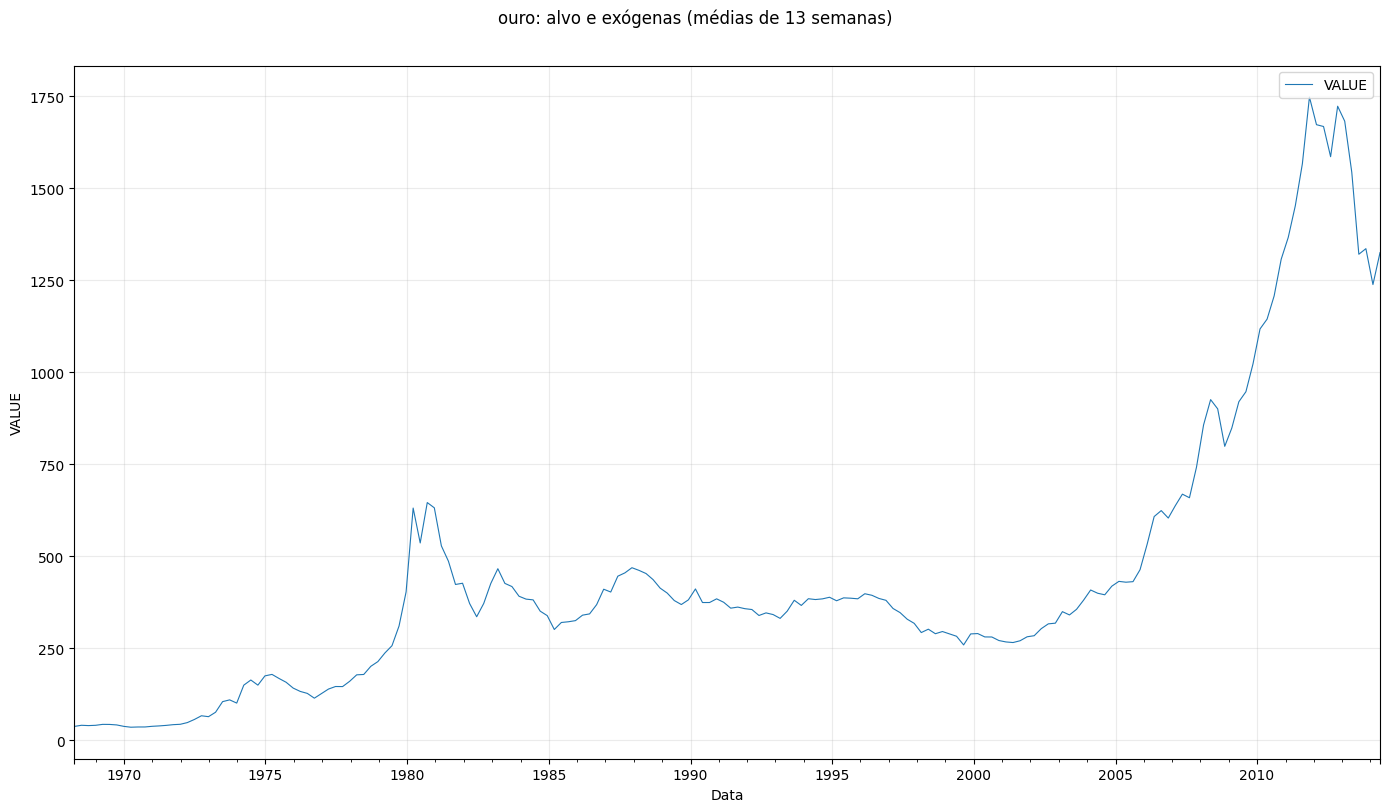

Decisão: preservar valores extremos plausíveis; não aplicar clipping global.
O alvo não é imputado; exógenas usam forward-fill causal limitado a 0 período(s).


In [6]:
# Diagnóstico visual e sinais de outlier, sem remoção automática.
def diagnosticar_exploracao(dados, colunas, fator_iqr=1.5):
    faltantes = [coluna for coluna in colunas if coluna not in dados.columns]
    if faltantes:
        raise KeyError(f'Colunas ausentes na base: {faltantes}')
    linhas = []
    for coluna in colunas:
        serie = pd.to_numeric(dados[coluna], errors='coerce')
        validos = serie.dropna()
        q1, q3 = validos.quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - fator_iqr * iqr, q3 + fator_iqr * iqr
        outliers = ((validos < inferior) | (validos > superior)).sum()
        linhas.append({
            'variavel': coluna, 'n': int(validos.size),
            'ausentes': int(serie.isna().sum()), 'media': float(validos.mean()),
            'desvio_padrao': float(validos.std()), 'minimo': float(validos.min()),
            'q1': float(q1), 'mediana': float(validos.median()), 'q3': float(q3),
            'maximo': float(validos.max()), 'limite_iqr_inferior': float(inferior),
            'limite_iqr_superior': float(superior), 'sinais_outlier_iqr': int(outliers),
            'percentual_outlier_iqr': float(outliers / max(1, validos.size)),
        })
    return pd.DataFrame(linhas).set_index('variavel')

colunas_exploracao = [TARGET_COLUMN] + EXOG_COLUMNS
resumo_exploracao = diagnosticar_exploracao(df, colunas_exploracao)
display(resumo_exploracao.round(3))

fig, axes = plt.subplots(
    len(colunas_exploracao), 1,
    figsize=(14, max(8, 2.2 * len(colunas_exploracao))), sharex=True,
)
axes = np.atleast_1d(axes)
for ax, coluna in zip(axes, colunas_exploracao):
    df[coluna].resample(VISUAL_RESAMPLE).mean().plot(ax=ax, linewidth=0.8, label=coluna)
    ax.set_ylabel(coluna)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('Data')
fig.suptitle(f'{BASE_NAME}: alvo e exógenas ({VISUAL_LABEL})', y=1.01)
plt.tight_layout()
plt.show()

print('Decisão: preservar valores extremos plausíveis; não aplicar clipping global.')
print(
    'O alvo não é imputado; exógenas usam forward-fill causal limitado a '
    f"{metadados_base['limite_ffill']} período(s)."
)

# 2. Sazonalidade


## Decomposição STL

A STL separa a série de treino em três componentes:

- **tendência:** movimento de longo prazo do preço;
- **sazonalidade:** possível padrão anual de 52 semanas;
- **resíduo:** variação não explicada pelos componentes anteriores.

Essa decomposição verifica se há recorrência anual relevante na série semanal.

STL no treino: 1968-04-05 00:00:00 a 2002-10-04 00:00:00 (1,801 semanas)


Força sazonal anual: 0.0000
Força de tendência: 0.9574


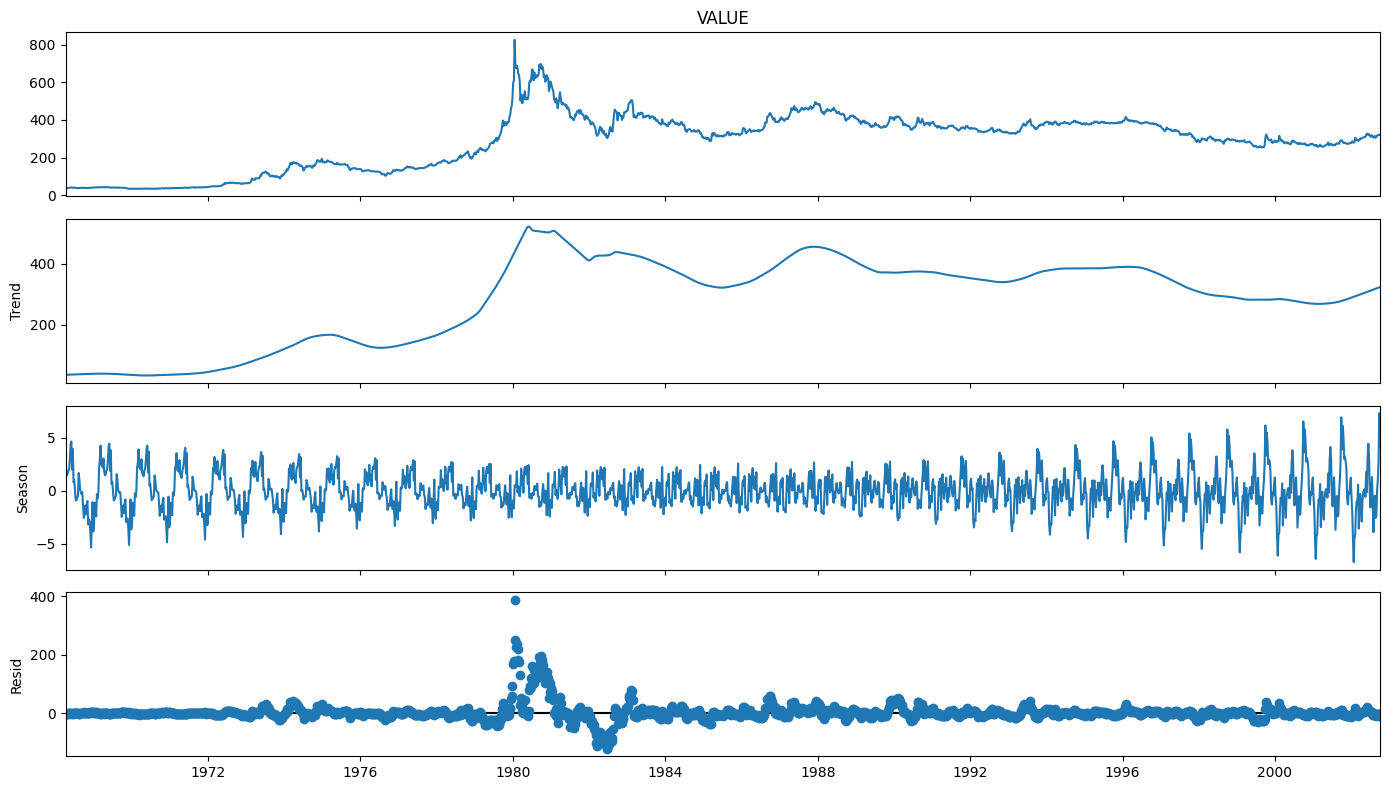

In [7]:
# Seleciona o maior trecho contínuo para a decomposição.
def maior_trecho_continuo(serie):
    observada = serie.dropna().sort_index()
    passo = pd.date_range('2000-01-01', periods=2, freq=FREQUENCY).to_series().diff().iloc[-1]
    blocos = observada.index.to_series().diff().ne(passo).cumsum()
    grupos = list(observada.groupby(blocos.to_numpy()))
    return max(grupos, key=lambda par: len(par[1]))[1].asfreq(FREQUENCY)

serie_stl = maior_trecho_continuo(df.loc[df.index < INICIO_TESTE, TARGET_COLUMN])
assert serie_stl.notna().all()
print(
    f'STL no treino: {serie_stl.index.min()} a {serie_stl.index.max()} '
    f'({len(serie_stl):,} {PERIOD_LABEL_PLURAL})'
)
stl_resultado = calcular_forca_sazonalidade(serie_stl, periodo=SEASONAL_PERIOD)
decomposicao = stl_resultado['decomposicao']
print(f"Força sazonal {SEASONAL_NAME}: {stl_resultado['forca_sazonalidade']:.4f}")
print(f"Força de tendência: {stl_resultado['forca_tendencia']:.4f}")
fig = decomposicao.plot(); fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

## Força da sazonalidade e resíduos

- **Força sazonal:** quantifica quanto da variação é explicado pelo ciclo anual.
- **Força da tendência:** indica a relevância das mudanças de longo prazo.
- **Resíduos:** devem apresentar média próxima de zero e pouca estrutura temporal.

A autocorrelação residual sugere quais dependências ainda podem não ter sido capturadas.

In [8]:
# Analisa a sazonalidade e os resíduos da decomposição.
analise_residuos_stl = analisar_componente_residual(
    decomposicao, lags=SEASONAL_PERIOD
)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl['autocorrelacao_residual'])

Média do residual: 2.767856
Desvio-padrão do residual: 29.741741


,lb_stat,lb_pvalue
1,1576.686003,0.0
2,2985.381273,0.0
3,4199.228898,0.0
4,5214.676945,0.0
5,6067.323785,0.0
6,6764.095362,0.0
7,7332.639277,0.0
8,7773.234663,0.0
9,8135.896749,0.0
10,8426.739214,0.0


# 3. Features e validação


## Pipeline de features

Como a base contém apenas data e alvo, as entradas combinam:

- **lags do preço:** histórico semanal até 52 semanas;
- **janelas móveis:** nível e variabilidade em diferentes horizontes;
- **calendário cíclico:** posição da semana ao longo do ano.

> Todas as features usam exclusivamente semanas anteriores à semana prevista.

In [9]:
# Gera features causais na grade temporal completa.
from features_temporais import construir_features_temporais

model_data = construir_features_temporais(
    df, TARGET_COLUMN,
    lags_alvo=TARGET_LAGS,
    lags_exogenas=EXOG_LAGS,
    janelas_moveis=ROLLING_WINDOWS,
    calendario=CALENDAR_COMPONENTS,
    indicadores_conhecidos=KNOWN_INDICATORS,
    horizonte=HORIZON,
    frequencia=FREQUENCY,
    remover_incompletos=True,
)

train = model_data.loc[model_data.index < INICIO_TESTE]
test = model_data.loc[model_data.index >= INICIO_TESTE]
if train.empty or test.empty or train.index.max() >= test.index.min():
    raise ValueError('Divisão temporal inválida.')
y_train, y_test = train['target'], test['target']
X_train, X_test = train.drop(columns='target'), test.drop(columns='target')
# Preve a variacao semanal sobre o ultimo valor conhecido.
y_train_delta = y_train - X_train['target_lag_1']
y_test_delta = y_test - X_test['target_lag_1']


print(f'Features: {X_train.shape[1]} | treino: {len(train):,} | teste final: {len(test):,}')
print(f'Corte comum: {FIM_TREINO} -> {INICIO_TESTE}')

Features: 18 | treino: 1,749 | teste final: 601
Corte comum: 2002-10-04 00:00:00 -> 2002-10-11 00:00:00


## Escalonamento

O MLP é sensível a diferenças de escala entre as variáveis, para combater isso devemos escalonar.
- **StandardScaler:** centraliza cada feature e ajusta sua dispersão, favorecendo a otimização dos pesos.
- **Sem vazamento:** imputador e scaler aprendem somente com o trecho de treino e apenas transformam validação e teste.


In [10]:
# Ajusta o escalonamento apenas no trecho de treino.
def validar_X(X, nome):
    if not isinstance(X, pd.DataFrame) or X.empty:
        raise ValueError(f'{nome} deve ser um DataFrame não vazio')
    nao_numericas = X.select_dtypes(exclude='number').columns.tolist()
    if nao_numericas:
        raise TypeError(f'{nome} contém colunas não numéricas: {nao_numericas}')
    if np.isinf(X.to_numpy(dtype=float)).any():
        raise ValueError(f'{nome} contém valores infinitos')
    if isinstance(X.index, pd.DatetimeIndex) and not X.index.is_monotonic_increasing:
        raise ValueError(f'{nome} deve estar em ordem temporal crescente')

def criar_escalonador(tipo):
    if tipo == 'standard':
        return StandardScaler()
    if tipo == 'minmax':
        return MinMaxScaler()
    raise ValueError("tipo deve ser 'standard' ou 'minmax'")

n_validacao = max(MIN_VALIDATION_SAMPLES, int(len(X_train) * VALIDATION_RATIO))
X_ajuste, X_validacao = X_train.iloc[:-n_validacao], X_train.iloc[-n_validacao:]
y_ajuste, y_validacao = y_train.iloc[:-n_validacao], y_train.iloc[-n_validacao:]
preprocessador_validacao = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalonador', criar_escalonador(SCALER)),
])
X_ajuste_sc = preprocessador_validacao.fit_transform(X_ajuste)
X_validacao_sc = preprocessador_validacao.transform(X_validacao)
escalonador_validacao = preprocessador_validacao.named_steps['escalonador']
if int(escalonador_validacao.n_samples_seen_) != len(X_ajuste):
    raise AssertionError('O escalonador consultou dados fora da janela de ajuste.')
diagnostico_escala = pd.DataFrame({
    'media_ajuste_escalado': X_ajuste_sc.mean(axis=0),
    'media_validacao_escalada': X_validacao_sc.mean(axis=0),
}, index=X_train.columns)
display(diagnostico_escala.head(10).round(4))
print('Escala validada: fit no passado; validação recebeu somente transform().')

,media_ajuste_escalado,media_validacao_escalada
target_lag_1,0.0,-0.0556
target_lag_2,0.0,-0.0543
target_lag_3,0.0,-0.0530
target_lag_4,0.0,-0.0516
target_lag_8,-0.0,-0.0454
target_lag_13,-0.0,-0.0376
target_lag_26,0.0,-0.0109
target_lag_52,0.0,0.0750
target_roll_mean_4,-0.0,-0.0537
target_roll_std_4,-0.0,-0.1809


Escala validada: fit no passado; validação recebeu somente transform().


## Validação temporal

- São usados **três folds cronológicos de seis meses**.
- Em cada fold, o treino sempre ocorre antes da validação.
- A configuração é escolhida pela média do MAE nos folds.
- No teste final, modelo e scaler permanecem congelados.

Esse protocolo simula o uso real e mantém o teste final independente da seleção do modelo.


In [11]:
# Cria três folds cronológicos de seis meses.
fim_desenvolvimento = INICIO_TESTE
folds, linhas_folds = [], []
for i in range(N_SPLITS_VALIDACAO):
    inicio_val = fim_desenvolvimento - pd.DateOffset(
        months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i)
    )
    fim_val = fim_desenvolvimento - pd.DateOffset(
        months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i - 1)
    )
    ia = np.flatnonzero(X_train.index < inicio_val)
    iv = np.flatnonzero((X_train.index >= inicio_val) & (X_train.index < fim_val))
    if not len(ia) or not len(iv):
        raise ValueError('Fold temporal vazio.')
    assert X_train.index[ia].max() < X_train.index[iv].min() < INICIO_TESTE
    folds.append((ia, iv))
    linhas_folds.append({
        'fold': i + 1, 'treino_ate': X_train.index[ia].max(),
        'validacao_inicio': X_train.index[iv].min(),
        'validacao_fim': X_train.index[iv].max(),
        'n_treino': len(ia), 'n_validacao': len(iv),
    })
fold_table = pd.DataFrame(linhas_folds)
display(fold_table)
np.testing.assert_allclose(
    model_data['target_lag_1'], df[TARGET_COLUMN].shift(1).reindex(model_data.index)
)
print(f'Origens finais: {len(X_test):,} | horizonte: {HORIZON} {PERIOD_LABEL} | modelo congelado no teste.')

,fold,treino_ate,validacao_inicio,validacao_fim,n_treino,n_validacao
0,1,2001-04-06,2001-04-13,2001-10-05,1671,26
1,2,2001-10-05,2001-10-12,2002-04-05,1697,26
2,3,2002-04-05,2002-04-12,2002-10-04,1723,26


Origens finais: 601 | horizonte: 1 semana | modelo congelado no teste.


# 4. Modelagem MLP


## Arquitetura e otimização

Cinco configurações compactas são comparadas variando:

- quantidade de camadas e neurônios;
- função de ativação e otimizador;
- regularização `alpha` e limite de épocas.

**Critério de seleção:** menor MAE médio nos folds temporais. Os 15% finais de cada treino controlam o **early stopping**, interrompendo o ajuste quando a validação deixa de melhorar.


In [12]:
# Avalia as configurações com early stopping e validação temporal.
def treinar_com_early_stopping(configuracao, X_desenvolvimento, y_desenvolvimento):
    n_interno = max(MIN_VALIDATION_SAMPLES, int(len(X_desenvolvimento) * VALIDATION_RATIO))
    X_fit, X_val = X_desenvolvimento.iloc[:-n_interno], X_desenvolvimento.iloc[-n_interno:]
    y_fit, y_val = y_desenvolvimento.iloc[:-n_interno], y_desenvolvimento.iloc[-n_interno:]
    preprocessador = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalonador', criar_escalonador(SCALER)),
    ])
    X_fit_sc = preprocessador.fit_transform(X_fit)
    X_val_sc = preprocessador.transform(X_val)
    escalonador_y = StandardScaler()
    y_fit_sc = escalonador_y.fit_transform(y_fit.to_numpy().reshape(-1, 1)).ravel()
    modelo = MLPRegressor(
        hidden_layer_sizes=configuracao['hidden_layer_sizes'],
        activation=configuracao['activation'], solver=configuracao['solver'],
        alpha=configuracao['alpha'], batch_size=BATCH_SIZE, max_iter=1,
        warm_start=True, early_stopping=False, shuffle=True, random_state=SEED,
    )
    melhor_modelo, melhor_mae, melhor_epoca, sem_melhora = None, np.inf, 0, 0
    linhas = []
    inicio_amostra = max(0, len(X_fit_sc) - MAX_AMOSTRA_MAE_TREINO)
    for epoca in range(1, configuracao['max_iter'] + 1):
        modelo.partial_fit(X_fit_sc, y_fit_sc)
        previsto_fit = escalonador_y.inverse_transform(
            modelo.predict(X_fit_sc[inicio_amostra:]).reshape(-1, 1)
        ).ravel()
        previsto_val = escalonador_y.inverse_transform(
            modelo.predict(X_val_sc).reshape(-1, 1)
        ).ravel()
        mae_treino = mean_absolute_error(
            y_fit.iloc[inicio_amostra:], previsto_fit
        )
        mae_validacao = mean_absolute_error(y_val, previsto_val)
        linhas.append({'epoca': epoca, 'MAE_treino': mae_treino, 'MAE_validacao': mae_validacao})
        if mae_validacao < melhor_mae - MIN_DELTA:
            melhor_modelo, melhor_mae, melhor_epoca = deepcopy(modelo), mae_validacao, epoca
            sem_melhora = 0
        else:
            sem_melhora += 1
            if sem_melhora >= PATIENCE:
                break
    return preprocessador, escalonador_y, melhor_modelo, pd.DataFrame(linhas), melhor_epoca, float(melhor_mae)

inicio_busca = time.perf_counter()
resultados_folds = []
for configuracao in CANDIDATOS_MLP:
    for numero_fold, (ia, iv) in enumerate(folds, start=1):
        preprocessador, escalonador_y, modelo, _, melhor_epoca, mae_interno = treinar_com_early_stopping(
            configuracao, X_train.iloc[ia], y_train_delta.iloc[ia]
        )
        previsto_fold = escalonador_y.inverse_transform(
            modelo.predict(preprocessador.transform(X_train.iloc[iv])).reshape(-1, 1)
        ).ravel()
        resultados_folds.append({
            'nome': configuracao['nome'], 'fold': numero_fold,
            'MAE_validacao': mean_absolute_error(y_train_delta.iloc[iv], previsto_fold),
            'melhor_epoca': melhor_epoca, 'MAE_early_stopping': mae_interno,
        })
        print(
            f"{configuracao['nome']} | fold {numero_fold}/{len(folds)} | "
            f"MAE={resultados_folds[-1]['MAE_validacao']:.4f} {TARGET_UNIT} | época={melhor_epoca}",
            flush=True,
        )

df_folds = pd.DataFrame(resultados_folds)
tabela_busca = (df_folds.groupby('nome', as_index=False)
    .agg(MAE_validacao=('MAE_validacao', 'mean'),
         desvio_MAE=('MAE_validacao', 'std'),
         mediana_melhor_epoca=('melhor_epoca', 'median'))
    .sort_values('MAE_validacao').reset_index(drop=True))
melhor_nome = tabela_busca.loc[0, 'nome']
melhor_configuracao = next(
    configuracao.copy() for configuracao in CANDIDATOS_MLP
    if configuracao['nome'] == melhor_nome
)
_, _, _, historico_mlp, melhor_epoca_final, mae_interno_final = treinar_com_early_stopping(
    melhor_configuracao, X_train, y_train_delta
)
melhor_configuracao['melhor_epoca'] = melhor_epoca_final
tempo_busca = time.perf_counter() - inicio_busca
display(tabela_busca.round(4))
display(df_folds.round(4))
print(f'Configuração selecionada: {melhor_nome} | busca: {tempo_busca / 60:.2f} min')

simples_32_relu_adam | fold 1/3 | MAE=3.9141 unidade monetária | época=17


simples_32_relu_adam | fold 2/3 | MAE=4.4682 unidade monetária | época=18


simples_32_relu_adam | fold 3/3 | MAE=4.0554 unidade monetária | época=17


media_64_relu_adam | fold 1/3 | MAE=3.8693 unidade monetária | época=1


media_64_relu_adam | fold 2/3 | MAE=4.3693 unidade monetária | época=1


...

simples_32_relu_sgd | fold 2/3 | MAE=4.5071 unidade monetária | época=30


simples_32_relu_sgd | fold 3/3 | MAE=4.0465 unidade monetária | época=29


,nome,MAE_validacao,desvio_MAE,mediana_melhor_epoca
0,aula_64x64_relu_adam,4.0613,0.4939,1.0
1,simples_32_relu_adam,4.1459,0.2879,17.0
2,media_64_relu_adam,4.1727,0.2666,1.0
3,simples_32_relu_sgd,4.2248,0.2472,29.0
4,simples_32_tanh_adam,4.4448,0.3817,9.0


,nome,fold,MAE_validacao,melhor_epoca,MAE_early_stopping
0,simples_32_relu_adam,1,3.9141,17,4.0914
1,simples_32_relu_adam,2,4.4682,18,4.2290
2,simples_32_relu_adam,3,4.0554,17,4.2880
3,media_64_relu_adam,1,3.8693,1,4.0584
4,media_64_relu_adam,2,4.3693,1,4.2544
5,media_64_relu_adam,3,4.2795,1,4.2947
6,aula_64x64_relu_adam,1,3.7197,1,3.9445
7,aula_64x64_relu_adam,2,4.6276,1,4.0440
8,aula_64x64_relu_adam,3,3.8366,1,4.1822
9,simples_32_tanh_adam,1,4.6309,9,3.9499


Configuração selecionada: aula_64x64_relu_adam | busca: 0.06 min


## Previsão fora da amostra

Após a seleção, o MLP é reajustado em todo o treino e prevê o teste final com horizonte de **uma semana**.

Principais medidas:

- **MAE:** erro absoluto médio na unidade do preço;
- **RMSE:** penaliza mais os erros grandes;
- **R²:** proporção da variabilidade explicada;
- **sMAPE:** erro percentual simétrico;
- **viés:** indica tendência de superestimar ou subestimar.
**Experimento revisado:** o MLP prevê a variação semanal em relação ao último valor observado e soma esse valor à previsão. Essa revisão foi motivada pela inspeção do erro no teste; portanto, o MAE revisado é exploratório e precisa dessa ressalva no relatório. A arquitetura e a época continuam escolhidas somente nos folds do treino.


C:\Users\gabrieloliveira-ieg\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


,conjunto,n,MAE,MSE,RMSE,MAPE_percent,sMAPE_percent,R2,vies_medio
0,treino,1749,5.5287,121.6900,11.0313,1.8450,1.8507,0.9938,1.2248
1,teste_final,601,22.6521,974.5416,31.2176,2.3612,2.3812,0.9954,12.1403


,modelo,origem,ultima_observacao_disponivel,fim_intervalo_previsto,data,passo,real,previsto,residuo,persistencia,sazonal_periodo
0,MLP Regressor,2002-10-11,2002-10-04,2002-10-18,2002-10-11,1,317.10,321.782801,-4.682801,321.65,282.85
1,MLP Regressor,2002-10-18,2002-10-11,2002-10-25,2002-10-18,1,312.45,317.040167,-4.590167,317.10,278.70
2,MLP Regressor,2002-10-25,2002-10-18,2002-11-01,2002-10-25,1,312.30,312.175265,0.124735,312.45,276.95
3,MLP Regressor,2002-11-01,2002-10-25,2002-11-08,2002-11-01,1,318.75,311.708592,7.041408,312.30,280.20
4,MLP Regressor,2002-11-08,2002-11-01,2002-11-15,2002-11-08,1,322.55,317.914925,4.635075,318.75,277.30


,configuracao,epocas_executadas,melhor_epoca,melhor_MAE_validacao,patience,tempo_busca_min,tempo_avaliacao_min
0,aula_64x64_relu_adam,21,1,4.061304,20,0.0616,0.000821


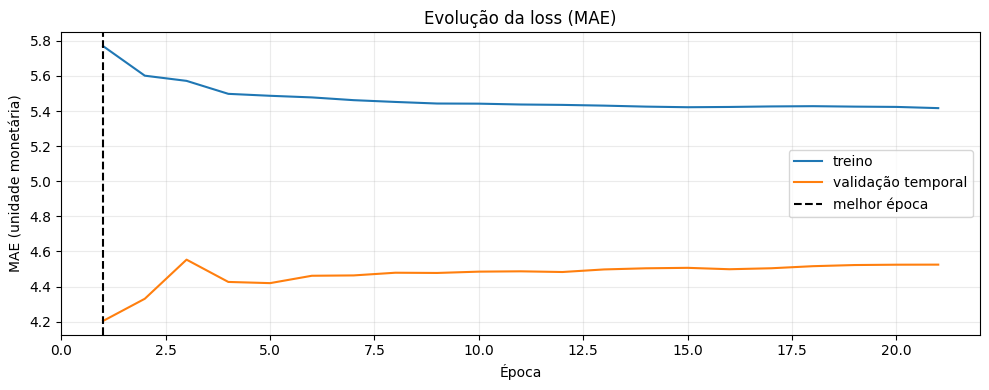

In [13]:
# Reajusta o modelo no treino completo e prevê o teste final.
def avaliar_previsoes(y, previsto, conjunto='teste'):
    residuo = (y - previsto).rename('residuo')
    mse = mean_squared_error(y, previsto)
    denominador = np.abs(y.to_numpy()) + np.abs(previsto.to_numpy())
    smape = np.mean(np.divide(
        2 * np.abs(y.to_numpy() - previsto.to_numpy()), denominador,
        out=np.zeros_like(denominador, dtype=float), where=denominador != 0
    )) * 100
    mape = (
        np.mean(np.abs((y.to_numpy() - previsto.to_numpy()) / y.to_numpy())) * 100
        if np.all(y.to_numpy() > 0) else np.nan
    )
    metricas = pd.DataFrame([{
        'conjunto': conjunto, 'n': len(y), 'MAE': mean_absolute_error(y, previsto),
        'MSE': mse, 'RMSE': mse ** 0.5, 'MAPE_percent': mape,
        'sMAPE_percent': smape, 'R2': r2_score(y, previsto),
        'vies_medio': residuo.mean(),
    }])
    return metricas, residuo

parametros_finais = {
    chave: melhor_configuracao[chave]
    for chave in ['hidden_layer_sizes', 'activation', 'solver', 'alpha']
}
regressor_mlp = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalonador', criar_escalonador(SCALER)),
    ('mlp', MLPRegressor(
        **parametros_finais, batch_size=BATCH_SIZE,
        max_iter=max(1, int(melhor_configuracao['melhor_epoca'])),
        early_stopping=False, shuffle=True, random_state=SEED,
    )),
])
modelo_mlp = TransformedTargetRegressor(
    regressor=regressor_mlp, transformer=StandardScaler()
)
inicio_avaliacao = time.perf_counter()
modelo_mlp.fit(X_train, y_train_delta)
previsao_treino = pd.Series(modelo_mlp.predict(X_train), index=y_train.index, name='previsao') + X_train['target_lag_1']
metricas_treino, residuos_treino = avaliar_previsoes(y_train, previsao_treino, 'treino')

previsao_mlp = pd.Series(modelo_mlp.predict(X_test), index=y_test.index, name='previsao') + X_test['target_lag_1']
metricas_mlp, residuos_mlp = avaliar_previsoes(y_test, previsao_mlp, 'teste_final')
tempo_avaliacao = time.perf_counter() - inicio_avaliacao
metricas_comparacao = pd.concat([metricas_treino, metricas_mlp], ignore_index=True)
display(metricas_comparacao.round(4))
if metricas_mlp['MAPE_percent'].isna().any():
    print('MAPE omitido porque o alvo contém zero ou valores negativos; use sMAPE.')
wf = pd.DataFrame({
    'modelo': 'MLP Regressor', 'origem': X_test.index,
    'ultima_observacao_disponivel': X_test.index - pd.tseries.frequencies.to_offset(FREQUENCY),
    'fim_intervalo_previsto': X_test.index + pd.tseries.frequencies.to_offset(FREQUENCY),
    'data': X_test.index, 'passo': HORIZON,
    'real': y_test.to_numpy(), 'previsto': previsao_mlp.to_numpy(),
    'residuo': residuos_mlp.to_numpy(),
    'persistencia': X_test['target_lag_1'].to_numpy(),
    'sazonal_periodo': X_test[f'target_lag_{SEASONAL_PERIOD}'].to_numpy(),
})
previsoes_mlp = wf.set_index('data')[['real', 'previsto', 'residuo']]
display(wf.head())

resumo_early_stopping = {
    'configuracao': melhor_nome,
    'epocas_executadas': len(historico_mlp),
    'melhor_epoca': int(melhor_configuracao['melhor_epoca']),
    'melhor_MAE_validacao': tabela_busca.loc[0, 'MAE_validacao'],
    'patience': PATIENCE,
    'tempo_busca_min': tempo_busca / 60,
    'tempo_avaliacao_min': tempo_avaliacao / 60,
}
display(pd.DataFrame([resumo_early_stopping]))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico_mlp['epoca'], historico_mlp['MAE_treino'], label='treino')
ax.plot(historico_mlp['epoca'], historico_mlp['MAE_validacao'], label='validação temporal')
ax.axvline(resumo_early_stopping['melhor_epoca'], color='black', linestyle='--', label='melhor época')
ax.set(title='Evolução da loss (MAE)', xlabel='Época', ylabel=f'MAE ({TARGET_UNIT})')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()



## Síntese técnica

- **Funcionamento:** aprende relações não lineares entre histórico, variáveis passadas e ciclos de calendário.
- **Saída:** um neurônio linear produz uma previsão contínua na unidade do alvo.
- **Vantagens:** flexibilidade, inferência rápida e interação entre diferentes features.
- **Limitações:** sensibilidade à escala e à inicialização, extrapolação fraca e menor interpretabilidade.

In [14]:
# Resume as propriedades e os resultados do modelo selecionado.
print('Arquitetura selecionada:', melhor_configuracao['hidden_layer_sizes'])
print(f'Saída linear para previsão contínua em {TARGET_UNIT}.')
print('O sklearn otimiza erro quadrático; arquitetura e época são selecionadas por MAE temporal.')
print(f'Early stopping: patience={PATIENCE}; o refit final usa a melhor época no treino completo.')
print('Teste: modelo congelado preve a variacao sobre o ultimo valor conhecido em cada origem.')
print('Limitações: sensibilidade à escala, extrapolação fraca e dependência dos lags observados.')
display(metricas_comparacao.round(4))

Arquitetura selecionada: (64, 64)
Saída linear para previsão contínua em unidade monetária.
O sklearn otimiza erro quadrático; arquitetura e época são selecionadas por MAE temporal.
Early stopping: patience=20; o refit final usa a melhor época no treino completo.
Teste: modelo congelado preve a variacao sobre o ultimo valor conhecido em cada origem.
Limitações: sensibilidade à escala, extrapolação fraca e dependência dos lags observados.


,conjunto,n,MAE,MSE,RMSE,MAPE_percent,sMAPE_percent,R2,vies_medio
0,treino,1749,5.5287,121.6900,11.0313,1.8450,1.8507,0.9938,1.2248
1,teste_final,601,22.6521,974.5416,31.2176,2.3612,2.3812,0.9954,12.1403


# 5. Avaliação


## Comparação com baselines

O resultado do MLP é comparado com referências simples:

- **persistência:** repete o preço da semana anterior;
- **sazonal ingênuo:** repete o preço observado 52 semanas antes.

Superar esses baselines confirma que a rede acrescenta informação além da continuidade e de uma possível recorrência anual.

In [15]:
# Compara o MLP com os baselines no teste final.
def resumir_metricas(nome, real, previsto):
    erro = np.asarray(real) - np.asarray(previsto)
    return {
        'modelo': nome, 'n': len(erro),
        'MAE': float(np.abs(erro).mean()),
        'RMSE': float(np.sqrt(np.mean(erro ** 2))),
        'R2': float(r2_score(real, previsto)),
        'vies_real_menos_previsto': float(erro.mean()),
        'P90_erro_absoluto': float(np.quantile(np.abs(erro), 0.9)),
        'MaxAE': float(np.abs(erro).max()),
    }

metricas = pd.DataFrame([
    resumir_metricas('MLP Regressor', wf['real'], wf['previsto']),
    resumir_metricas(f'Persistência (1 {PERIOD_LABEL})', wf['real'], wf['persistencia']),
    resumir_metricas(f'Sazonal ingênuo ({SEASONAL_PERIOD} {PERIOD_LABEL_PLURAL})', wf['real'], wf['sazonal_periodo']),
])
mae_persistencia = metricas.loc[1, 'MAE']
metricas['ganho_MAE_vs_persistencia_pct'] = 100 * (1 - metricas['MAE'] / mae_persistencia)
display(metricas.round(4))
print(f'Busca: {tempo_busca / 60:.2f} min | treino e avaliação: {tempo_avaliacao / 60:.2f} min')
mensal = wf.set_index('data').resample('MS').apply({
    'residuo': lambda s: s.abs().mean(), 'real': 'count'
})
mensal.columns = ['MAE_MLP', 'n']
mensal['MAE_persistencia'] = (
    wf.set_index('data')['real'] - wf.set_index('data')['persistencia']
).abs().resample('MS').mean()


,modelo,n,MAE,RMSE,R2,vies_real_menos_previsto,P90_erro_absoluto,MaxAE,ganho_MAE_vs_persistencia_pct
0,MLP Regressor,601,22.6521,31.2176,0.9954,12.1403,49.1067,130.4563,-15.7284
1,Persistência (1 semana),601,19.5735,28.0047,0.9963,1.6636,44.0000,134.0000,0.0000
2,Sazonal ingênuo (52 semanas),601,156.0030,202.4365,0.8082,87.8002,324.6500,631.5000,-697.0128


Busca: 0.06 min | treino e avaliação: 0.00 min


## Diagnóstico dos resíduos

- **Real vs. previsto:** mostra aderência e erros extremos.
- **Resíduo vs. previsto:** ajuda a identificar viés e variância não constante.
- **ACF:** revela dependências remanescentes entre os erros.
- **Ljung–Box:** testa estatisticamente a presença de autocorrelação.

> Um p-valor baixo indica que ainda existe estrutura temporal não capturada pelo modelo.


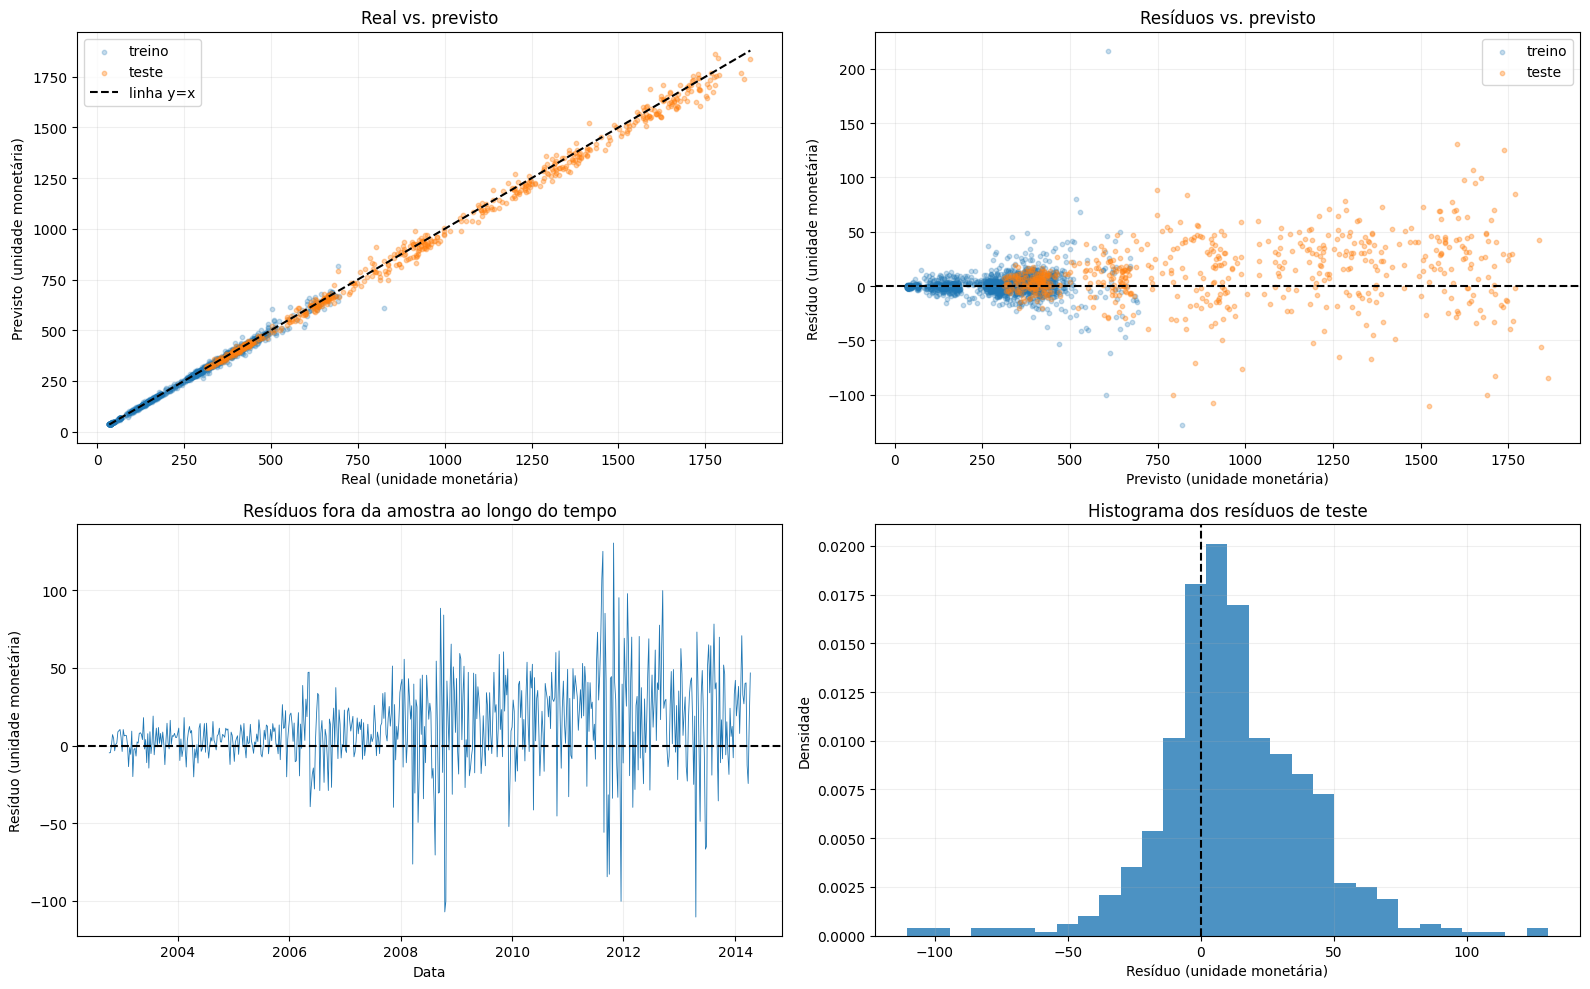

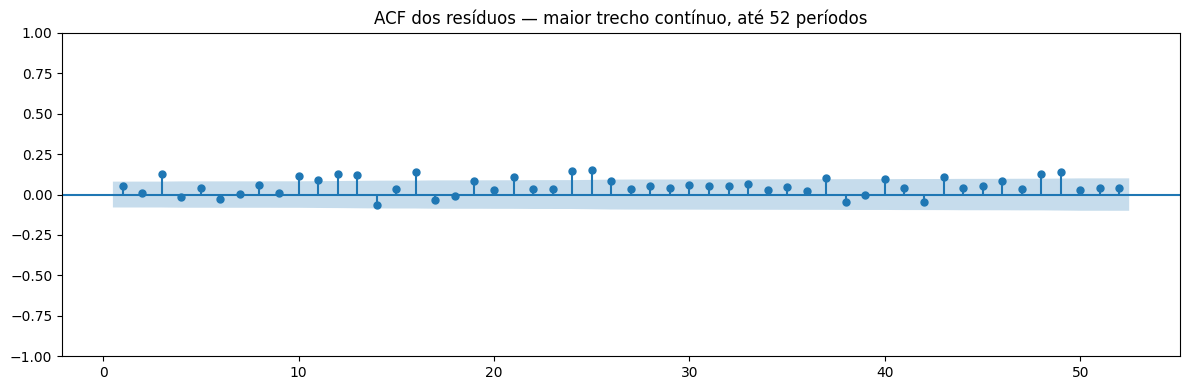

,lb_stat,lb_pvalue
lag_periodos,,
1,1.554059,2.125373e-01
4,11.695544,1.976488e-02
13,47.643507,7.520365e-06
26,108.685684,4.427914e-12
52,181.723405,2.789262e-16


Há evidência de autocorrelação residual (p < 0,05); ainda resta estrutura temporal não capturada.


In [16]:
# Diagnostica os resíduos fora da amostra.
residuos_mlp = wf.set_index('data')['residuo'].sort_index()
residuos_continuos = maior_trecho_continuo(residuos_mlp)
amostra_treino = previsao_treino.sample(
    n=min(5000, len(previsao_treino)), random_state=SEED
).index
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

axes[0].scatter(y_train.loc[amostra_treino], previsao_treino.loc[amostra_treino], alpha=0.25, s=10, label='treino')
axes[0].scatter(y_test, previsao_mlp, alpha=0.35, s=10, label='teste')
mn = min(y_train.min(), y_test.min(), previsao_treino.min(), previsao_mlp.min())
mx = max(y_train.max(), y_test.max(), previsao_treino.max(), previsao_mlp.max())
axes[0].plot([mn, mx], [mn, mx], '--', color='black', label='linha y=x')
axes[0].set(title='Real vs. previsto', xlabel=f'Real ({TARGET_UNIT})', ylabel=f'Previsto ({TARGET_UNIT})')
axes[0].legend()

axes[1].scatter(previsao_treino.loc[amostra_treino], residuos_treino.loc[amostra_treino], alpha=0.25, s=10, label='treino')
axes[1].scatter(previsao_mlp, residuos_mlp, alpha=0.35, s=10, label='teste')
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set(title='Resíduos vs. previsto', xlabel=f'Previsto ({TARGET_UNIT})', ylabel=f'Resíduo ({TARGET_UNIT})')
axes[1].legend()

axes[2].plot(residuos_mlp.index, residuos_mlp, linewidth=0.6)
axes[2].axhline(0, linestyle='--', color='black')
axes[2].set(title='Resíduos fora da amostra ao longo do tempo', xlabel='Data', ylabel=f'Resíduo ({TARGET_UNIT})')

axes[3].hist(residuos_mlp, bins=30, density=True, alpha=0.8)
axes[3].axvline(0, linestyle='--', color='black')
axes[3].set(title='Histograma dos resíduos de teste', xlabel=f'Resíduo ({TARGET_UNIT})', ylabel='Densidade')
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

acf_lag = min(MAX_ACF_LAG, len(residuos_continuos) - 1)
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(residuos_continuos, lags=acf_lag, zero=False, ax=ax)
ax.set_title(f'ACF dos resíduos — maior trecho contínuo, até {acf_lag} períodos')
plt.tight_layout(); plt.show()

lags_validos = [lag for lag in LJUNG_LAGS if lag < len(residuos_continuos)]
ljung_box_mlp = acorr_ljungbox(residuos_continuos, lags=lags_validos, return_df=True)
ljung_box_mlp.index.name = 'lag_periodos'
display(ljung_box_mlp)
if (ljung_box_mlp['lb_pvalue'] < 0.05).any():
    print('Há evidência de autocorrelação residual (p < 0,05); ainda resta estrutura temporal não capturada.')
else:
    print('Não há evidência de autocorrelação residual nos lags avaliados (p >= 0,05).')


## Importância das features

A importância por permutação embaralha uma feature por vez e mede o aumento do MAE:

- aumento maior significa maior contribuição preditiva;
- valores próximos de zero indicam pouca contribuição isolada;
- features correlacionadas podem dividir importância entre si.

O método melhora a interpretação sem alterar o modelo treinado.


,feature,importancia,desvio_importancia,metodo,coeficiente,p_valor
0,target_roll_mean_8,1.5821,0.0561,permutacao,NaN,NaN
1,target_lag_4,0.9339,0.0605,permutacao,NaN,NaN
2,target_roll_mean_26,0.7241,0.0385,permutacao,NaN,NaN
3,target_lag_8,0.5540,0.0508,permutacao,NaN,NaN
4,target_roll_mean_13,0.5515,0.0237,permutacao,NaN,NaN
5,target_roll_std_8,0.4754,0.0421,permutacao,NaN,NaN
6,target_lag_26,0.4191,0.0342,permutacao,NaN,NaN
7,target_lag_3,0.3332,0.0591,permutacao,NaN,NaN
8,target_roll_mean_4,0.2737,0.0169,permutacao,NaN,NaN
9,target_lag_52,0.1944,0.0222,permutacao,NaN,NaN


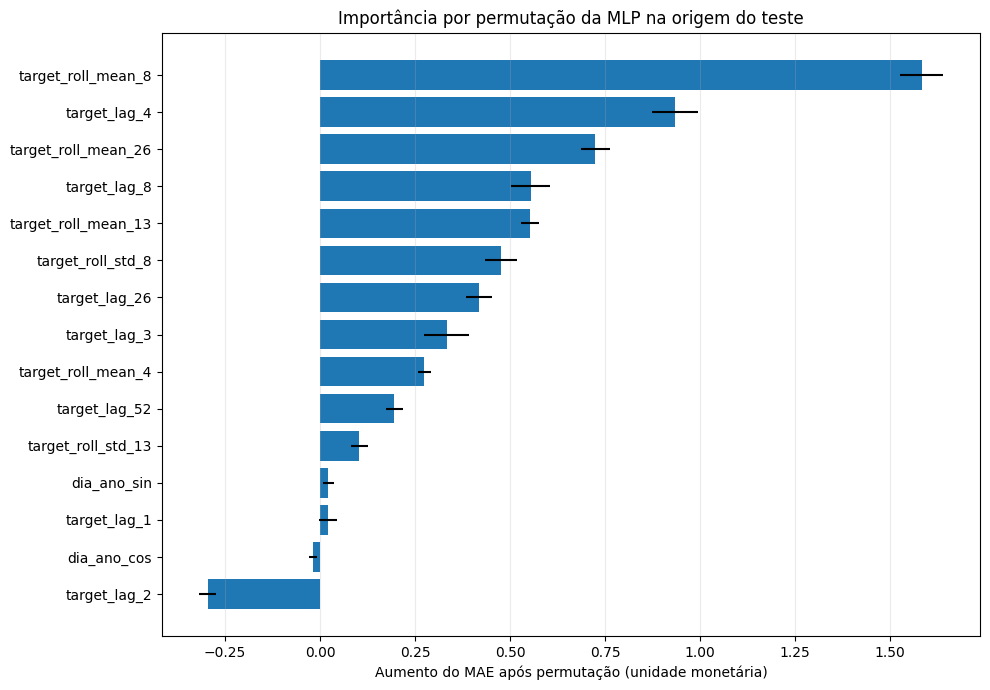

Principais features: target_roll_mean_8, target_lag_4, target_roll_mean_26, target_lag_8, target_roll_mean_13
A importância mede o aumento do MAE ao embaralhar cada feature.
A base não possui exógenas; a explicação depende do histórico do preço e do calendário.


In [17]:
# Estima a importância das features por permutação.
importancias_mlp = calcular_importancia_features(
    modelo_mlp, X_test, y_test, metodo='permutacao',
    n_repeticoes=10, seed=SEED, n_jobs=-1, max_amostras=3000,
)
display(importancias_mlp.head(15).round(4))
top = importancias_mlp.head(15).sort_values('importancia')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top['feature'], top['importancia'], xerr=top['desvio_importancia'])
ax.set_title('Importância por permutação da MLP na origem do teste')
ax.set_xlabel(f'Aumento do MAE após permutação ({TARGET_UNIT})')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); plt.show()
print('Principais features:', ', '.join(importancias_mlp.head(5)['feature']))
print('A importância mede o aumento do MAE ao embaralhar cada feature.')
print('A base não possui exógenas; a explicação depende do histórico do preço e do calendário.')


In [10]:
from IPython.display import display
from walk_forward import validar_previsoes
checagem = validar_previsoes(BASE_NAME, wf["data"], PROJECT_ROOT)
assert checagem["ok"], checagem
print(f"MAE RECONSTRUIDO: {np.mean(np.abs(wf["real"]-wf["previsto"])):.8f} | n={len(wf)}")
resultado = [{"data": str(d), "real": float(r), "previsto": float(v)} for d, r, v in wf[["data","real","previsto"]].itertuples(index=False, name=None)]
import base64, zlib, json
_carga_compacta = base64.b64encode(zlib.compress(json.dumps(resultado, ensure_ascii=False, separators=(',', ':'), allow_nan=False).encode('utf-8'), 9)).decode('ascii')
display({'application/vnd.series-temporais.previsoes+json': {'formato': 'json-zlib-base64', 'dados': _carga_compacta}}, raw=True)

MAE RECONSTRUIDO: 22.65206082 | n=601
